In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
cc_score = pd.read_csv(
    r"C:\Users\shrad\Downloads\india_personal_loan_default_risk_2026 - india_personal_loan_default_risk_2026.csv"
)

print(cc_score.shape)
print(cc_score.columns)
print(cc_score.dtypes)

(25002, 25)
Index(['applicant_id', 'age', 'gender', 'marital_status', 'city_tier', 'state',
       'employment_type', 'bank_account_vintage_years', 'monthly_income_inr',
       'existing_loans_count', 'existing_emi_monthly_inr',
       'credit_utilization_ratio_pct', 'num_credit_inquiries_last_6m',
       'late_payments_last_12m', 'loan_amount_requested_inr',
       'loan_tenure_months', 'loan_purpose', 'collateral_provided',
       'cibil_score', 'interest_rate_offered_pct', 'default_risk_score',
       'default_flag', 'Unnamed: 22', 'NEW_BANKCCTYEARS', 'NEW_EXISTING EMI'],
      dtype='object')
applicant_id                     object
age                             float64
gender                           object
marital_status                   object
city_tier                        object
state                            object
employment_type                  object
bank_account_vintage_years      float64
monthly_income_inr              float64
existing_loans_count            floa

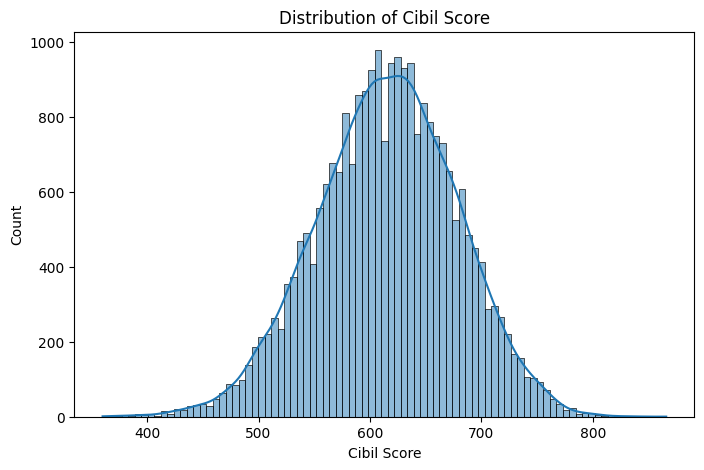

In [21]:
# Cibil score distribution

plt.figure(figsize=(8,5))
sns.histplot(cc_score["cibil_score"], kde=True)
plt.title("Distribution of Cibil Score")
plt.xlabel("Cibil Score")
plt.ylabel("Count")
plt.show()

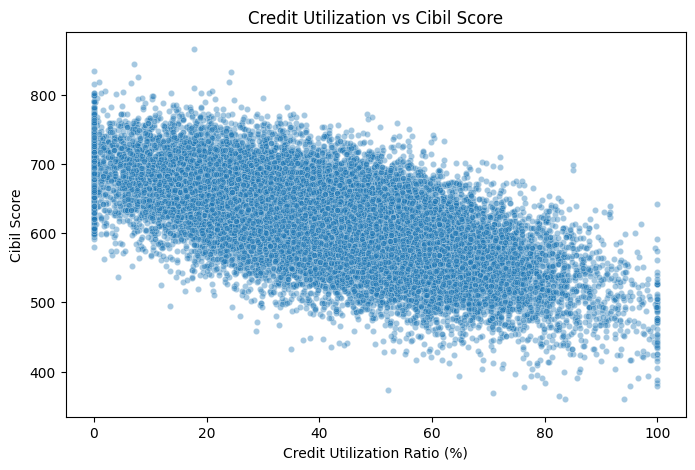

In [22]:
# Credit utilization vs Cibil score

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=cc_score,
    x="credit_utilization_ratio_pct",
    y="cibil_score",
    s=20,
    alpha=0.4
)
plt.title("Credit Utilization vs Cibil Score")
plt.xlabel("Credit Utilization Ratio (%)")
plt.ylabel("Cibil Score")
plt.show()



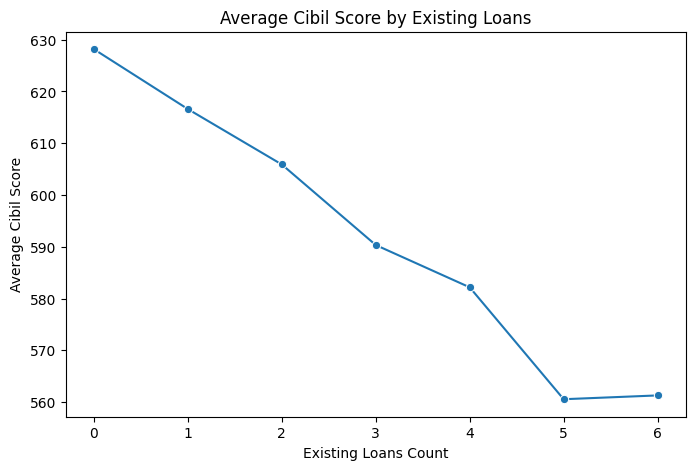

In [23]:
# Existing loans and Cibil score

loan_cibil = cc_score.groupby(
    "existing_loans_count",
    as_index=False
)["cibil_score"].mean()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=loan_cibil,
    x="existing_loans_count",
    y="cibil_score",
    marker="o"
)
plt.title("Average Cibil Score by Existing Loans")
plt.xlabel("Existing Loans Count")
plt.ylabel("Average Cibil Score")
plt.show()


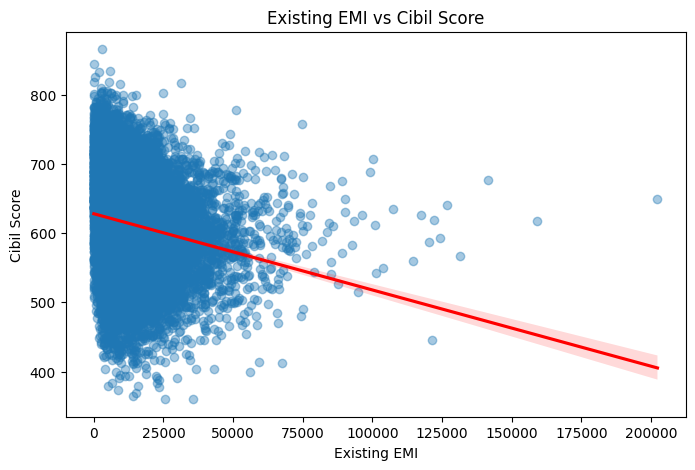

In [24]:

# Existing EMI vs Cibil score

plt.figure(figsize=(8,5))
sns.regplot(
    data=cc_score,
    x="NEW_EXISTING EMI",
    y="cibil_score",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)
plt.title("Existing EMI vs Cibil Score")
plt.xlabel("Existing EMI")
plt.ylabel("Cibil Score")
plt.show()




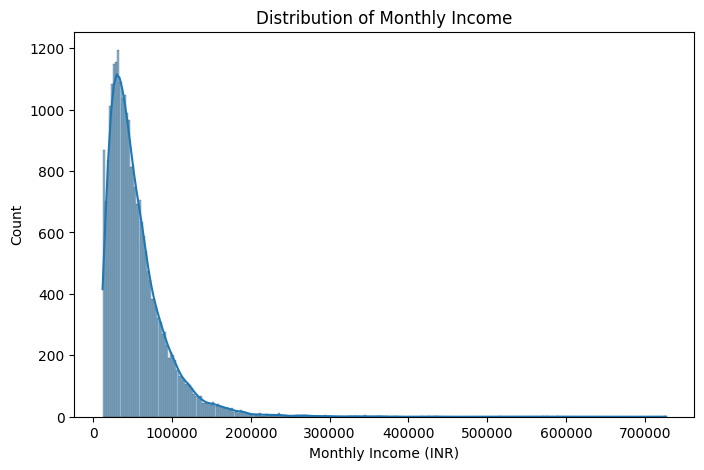

In [25]:
# Monthly income distribution

plt.figure(figsize=(8,5))
sns.histplot(
    cc_score["monthly_income_inr"],
    kde=True
)
plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income (INR)")
plt.ylabel("Count")
plt.show()

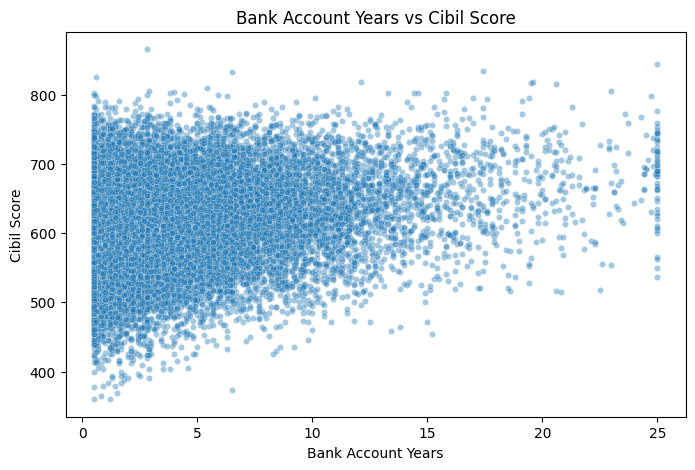

Correlation between Bank Account Years and Cibil Score: 0.2052807602348587


In [26]:
# Bank account years vs Cibil score

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=cc_score,
    x="NEW_BANKCCTYEARS",
    y="cibil_score",
    s=20,
    alpha=0.4
)
plt.title("Bank Account Years vs Cibil Score")
plt.xlabel("Bank Account Years")
plt.ylabel("Cibil Score")
plt.show()

print(
    "Correlation between Bank Account Years and Cibil Score:",
    cc_score["NEW_BANKCCTYEARS"].corr(cc_score["cibil_score"])
)




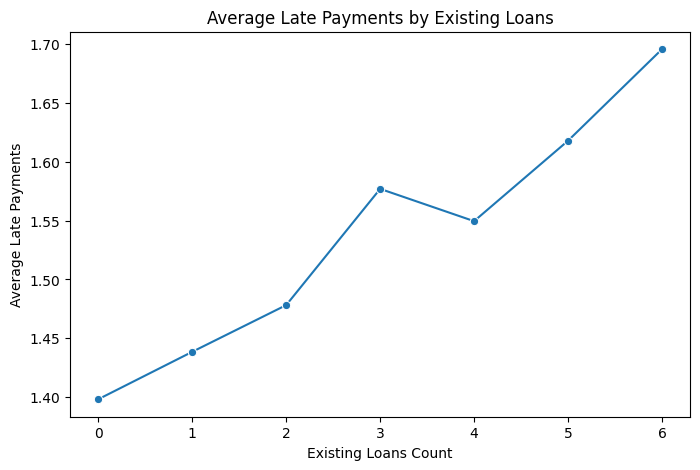

In [27]:
# Late payments and existing loans

loan_late = cc_score.groupby(
    "existing_loans_count",
    as_index=False
)["late_payments_last_12m"].mean()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=loan_late,
    x="existing_loans_count",
    y="late_payments_last_12m",
    marker="o"
)
plt.title("Average Late Payments by Existing Loans")
plt.xlabel("Existing Loans Count")
plt.ylabel("Average Late Payments")
plt.show()
